# 04 Momentum

**Book:** *Expected Returns* (Ilmanen)  
**Focus:** Build a runnable local momentum scaffold across equity, FX, commodity, and rates proxies using only internal parquet data.

## Proxy Scope And Local-Data Limits

1. This notebook uses only `data/market_data` parquet datasets in this repo.
2. Universe is limited to local liquid proxies: `SPY`, `DX-Y.NYB`, `GC=F`, `CL=F`, selected major FX pairs, and rates proxies (`^TNX`, `^FVX`) that are directly available in local price parquet.
3. Signals are lagged and applied to next-day returns (`t+1`) to avoid look-ahead.
4. This is a research scaffold, not a production multi-asset momentum system with full contract-rolled futures handling.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-29_expected_returns_ilmanen"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(STUDY_DIR) not in sys.path:
    sys.path.insert(0, str(STUDY_DIR))

from local_parquet import (
    DEFAULT_END,
    DEFAULT_START,
    business_days,
    load_price_series,
    read_catalog,
    simple_returns,
)

MOM_PANEL_CSV = STUDY_DIR / "04_momentum_panel.csv"
MOM_LATEST_RANK_CSV = STUDY_DIR / "04_momentum_latest_rank.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

catalog = read_catalog()
print("Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.")
print("Date range:", DEFAULT_START, "to", DEFAULT_END)
print("Catalog datasets:", sorted(catalog.keys()))

Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.
Date range: 2024-02-26 to 2026-02-27
Catalog datasets: ['commodities', 'equities', 'fed_liquidity', 'fx', 'ibkr_equities', 'ibkr_fx', 'macro_indicators', 'rates_yf', 'treasury_yields']


In [2]:
ASSET_META = {
    "SPY": "equity",
    "DX-Y.NYB": "fx",
    "EURUSD=X": "fx",
    "GBPUSD=X": "fx",
    "USDJPY=X": "fx",
    "GC=F": "commodity",
    "CL=F": "commodity",
    "^TNX": "rates",
    "^FVX": "rates",
}

days = business_days(DEFAULT_START, DEFAULT_END)
prices = load_price_series(list(ASSET_META), start=DEFAULT_START, end=DEFAULT_END, value_col="close")
prices = prices.reindex(days).ffill()
prices.index.name = "date"

asset_info = pd.Series(ASSET_META, name="asset_class").to_frame()
asset_info.index.name = "ticker"

print("Loaded tickers:", list(prices.columns))
print("Business-day observations:", len(prices))
asset_info

Loaded tickers: ['CL=F', 'DX-Y.NYB', 'EURUSD=X', 'GBPUSD=X', 'GC=F', 'SPY', 'USDJPY=X', '^FVX', '^TNX']
Business-day observations: 525


         asset_class
ticker              
SPY           equity
DX-Y.NYB          fx
EURUSD=X          fx
GBPUSD=X          fx
USDJPY=X          fx
GC=F       commodity
CL=F       commodity
^TNX           rates
^FVX           rates

In [3]:
LOOKBACK_DAYS = 252
SKIP_RECENT_DAYS = 21

# 12-1 momentum proxy at time t: log(P[t-21] / P[t-252]).
# We trade this signal on next-day returns (t+1) via shift(-1), avoiding look-ahead.
mom_score = np.log(prices.shift(SKIP_RECENT_DAYS) / prices.shift(LOOKBACK_DAYS))
ts_signal = np.sign(mom_score).replace(0.0, np.nan)
next_ret = simple_returns(prices).shift(-1)

ts_leg = ts_signal * next_ret
ts_mom_ew = ts_leg.mean(axis=1, skipna=True).rename("ts_mom_ew")

cs_rank = mom_score.rank(axis=1, pct=True)
cs_signal = (cs_rank - 0.5)
cs_signal = cs_signal.div(cs_signal.abs().sum(axis=1), axis=0)
cs_leg = cs_signal * next_ret
cs_mom_ls = cs_leg.sum(axis=1, min_count=2).rename("cs_mom_ls")

buy_hold_ew = next_ret.mean(axis=1, skipna=True).rename("buy_hold_ew")

panel = pd.concat([ts_mom_ew, cs_mom_ls, buy_hold_ew], axis=1).dropna()
panel.tail()

            ts_mom_ew  cs_mom_ls  buy_hold_ew
date                                         
2026-02-20   0.006553   0.007022    -0.001182
2026-02-23  -0.000378   0.000007    -0.001034
2026-02-24   0.002250   0.003480     0.003254
2026-02-25   0.000357  -0.000268    -0.002362
2026-02-26   0.001480   0.004395     0.000795

In [4]:
def ann_return(series: pd.Series, periods: int = 252) -> float:
    s = series.dropna()
    return float(s.mean() * periods) if len(s) else np.nan


def ann_vol(series: pd.Series, periods: int = 252) -> float:
    s = series.dropna()
    return float(s.std() * np.sqrt(periods)) if len(s) else np.nan


def ann_sharpe(series: pd.Series, periods: int = 252) -> float:
    r = ann_return(series, periods=periods)
    v = ann_vol(series, periods=periods)
    if pd.isna(v) or v == 0.0:
        return np.nan
    return r / v


summary = pd.DataFrame({
    "ann_return": panel.apply(ann_return),
    "ann_vol": panel.apply(ann_vol),
    "ann_sharpe": panel.apply(ann_sharpe),
    "hit_rate": (panel > 0).mean(),
}).round(4)

latest_date = mom_score.dropna(how="all").index[-1]
latest_rank = pd.DataFrame({
    "momentum_score": mom_score.loc[latest_date],
    "ts_signal": ts_signal.loc[latest_date],
    "asset_class": pd.Series(ASSET_META),
}).dropna()
latest_rank["rank_desc"] = latest_rank["momentum_score"].rank(ascending=False, method="dense")
latest_rank = latest_rank.sort_values("momentum_score", ascending=False)

print("Latest ranking date:", latest_date.date())
print(summary.to_string())
latest_rank.head(12)

Latest ranking date: 2026-02-27
             ann_return  ann_vol  ann_sharpe  hit_rate
ts_mom_ew        0.0509   0.0668      0.7624    0.5294
cs_mom_ls        0.1272   0.0815      1.5613    0.5588
buy_hold_ew      0.0575   0.0803      0.7164    0.5221


          momentum_score  ts_signal asset_class  rank_desc
GC=F            0.593069        1.0   commodity        1.0
SPY             0.216613        1.0      equity        2.0
EURUSD=X        0.092990        1.0          fx        3.0
GBPUSD=X        0.065807        1.0          fx        4.0
USDJPY=X        0.033569        1.0          fx        5.0
^TNX           -0.021300       -1.0       rates        6.0
CL=F           -0.033963       -1.0   commodity        7.0
^FVX           -0.069536       -1.0       rates        8.0
DX-Y.NYB       -0.073373       -1.0          fx        9.0

In [5]:
MOM_ASSET_SUMMARY_CSV = STUDY_DIR / "04_momentum_asset_summary.csv"
MOM_CLASS_SUMMARY_CSV = STUDY_DIR / "04_momentum_asset_class_summary.csv"

asset_ts_returns = (ts_signal * next_ret).copy()
fwd_21 = prices.shift(-21).div(prices).sub(1.0)

asset_rows = []
for ticker in prices.columns:
    strat = asset_ts_returns[ticker].dropna()
    if len(strat) == 0:
        continue
    long_mask = ts_signal[ticker] > 0
    short_mask = ts_signal[ticker] < 0
    asset_rows.append(
        {
            "ticker": ticker,
            "asset_class": ASSET_META[ticker],
            "obs": int(len(strat)),
            "ann_return": ann_return(strat),
            "ann_vol": ann_vol(strat),
            "ann_sharpe": ann_sharpe(strat),
            "hit_rate": float((strat > 0).mean()),
            "avg_fwd21_when_long": float(fwd_21[ticker][long_mask].dropna().mean()),
            "avg_fwd21_when_short": float(fwd_21[ticker][short_mask].dropna().mean()),
            "latest_score": float(mom_score.loc[latest_date, ticker]),
            "latest_signal": float(ts_signal.loc[latest_date, ticker]),
        }
    )

asset_summary_df = pd.DataFrame(asset_rows).set_index("ticker").sort_values("ann_sharpe", ascending=False).round(4)
asset_class_summary = asset_summary_df.groupby("asset_class")[["ann_return", "ann_vol", "ann_sharpe", "hit_rate"]].mean().round(4)

asset_summary_df.to_csv(MOM_ASSET_SUMMARY_CSV)
asset_class_summary.to_csv(MOM_CLASS_SUMMARY_CSV)

print("Saved asset summary to", MOM_ASSET_SUMMARY_CSV)
print("Saved asset-class summary to", MOM_CLASS_SUMMARY_CSV)
asset_summary_df


Saved asset summary to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/04_momentum_asset_summary.csv
Saved asset-class summary to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/04_momentum_asset_class_summary.csv


         asset_class  obs  ann_return  ann_vol  ann_sharpe  hit_rate  avg_fwd21_when_long  avg_fwd21_when_short  latest_score  latest_signal
ticker                                                                                                                                      
GC=F       commodity  272      0.5877   0.2514      2.3380    0.5772               0.0472                   NaN        0.5931            1.0
SPY           equity  272      0.0886   0.1878      0.4718    0.5221               0.0128                0.0411        0.2166            1.0
EURUSD=X          fx  272      0.0322   0.0769      0.4191    0.4890               0.0051                0.0370        0.0930            1.0
DX-Y.NYB          fx  272      0.0188   0.0713      0.2629    0.4669              -0.0317               -0.0029       -0.0734           -1.0
GBPUSD=X          fx  272      0.0044   0.0705      0.0618    0.4890               0.0044                0.0188        0.0658            1.0
CL=F       co

saved panel to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/04_momentum_panel.csv
saved latest ranking to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/04_momentum_latest_rank.csv


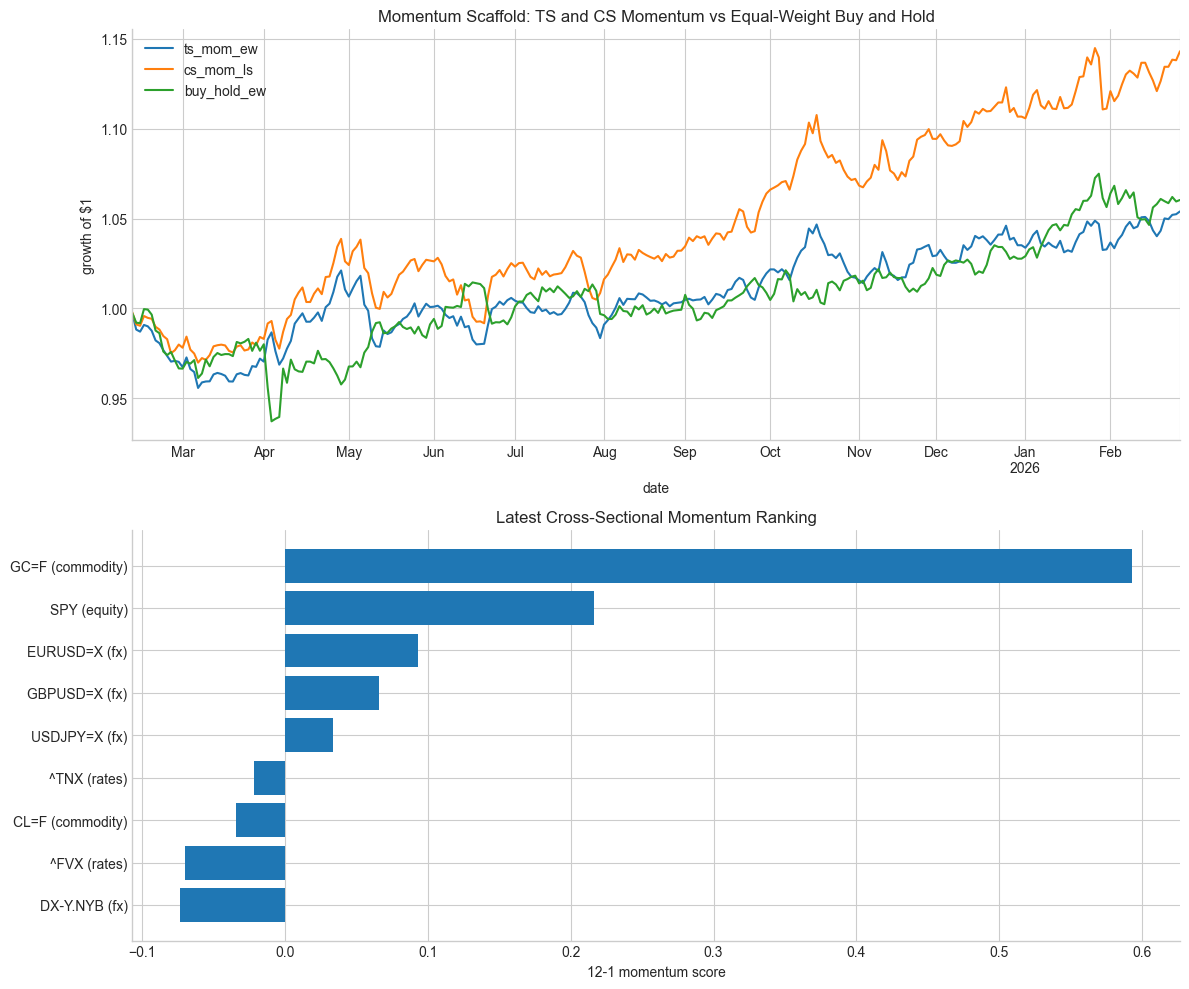

In [6]:
cum = (1.0 + panel).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

cum[["ts_mom_ew", "cs_mom_ls", "buy_hold_ew"]].plot(ax=axes[0], title="Momentum Scaffold: TS and CS Momentum vs Equal-Weight Buy and Hold")
axes[0].set_ylabel("growth of $1")

plot_rank = latest_rank.copy()
plot_rank["label"] = plot_rank.index + " (" + plot_rank["asset_class"] + ")"
plot_rank = plot_rank.sort_values("momentum_score", ascending=True)
axes[1].barh(plot_rank["label"], plot_rank["momentum_score"], color="tab:blue")
axes[1].set_title("Latest Cross-Sectional Momentum Ranking")
axes[1].set_xlabel("12-1 momentum score")

plt.tight_layout()
plt.show()

panel.to_csv(MOM_PANEL_CSV)
latest_rank.to_csv(MOM_LATEST_RANK_CSV)
print("saved panel to", MOM_PANEL_CSV)
print("saved latest ranking to", MOM_LATEST_RANK_CSV)